In [6]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from langchain_core.messages import AIMessageChunk
from rich import print as rprint
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
    profile={"max_input_tokens": 1_000_000}
)


作用：对历史消息列表进行
摘要&总结 ，达到
压缩上下文的效果。
原理：在
达到触发条件时，调用大模型对历史消息进行摘要，
放到消息列表最开始的位置。

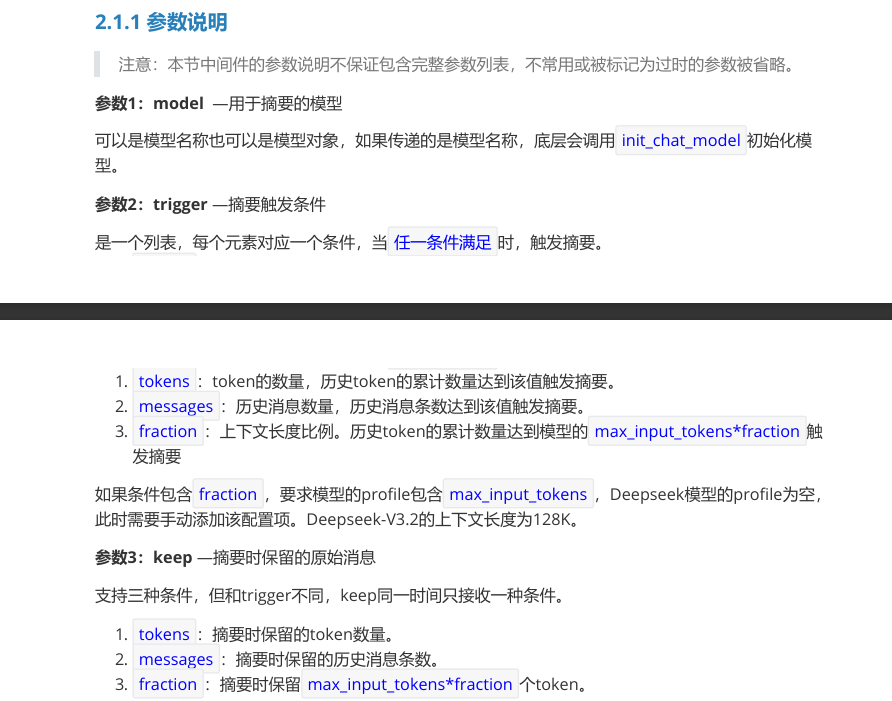
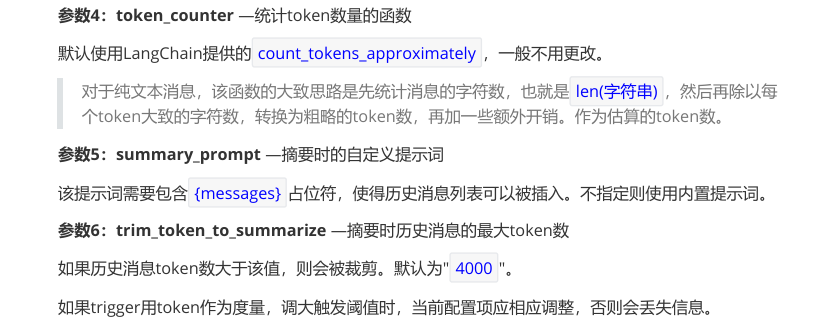

2.1.2 举例1
测试trigger、keep参数

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("你是个非常友好的AI助手"),
    HumanMessage("你好啊，我是老王，你是谁？"),
    AIMessage("你好老王，我是小王"),
    HumanMessage("好的小王，很高兴认识你"),
    AIMessage("你高兴得太早了"),
    HumanMessage("呵呵，你什么意思")
]
agent = create_agent(
    model=model,
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),
                ("messages", 6),
                ("fraction", 0.001)
            ],
            keep=("messages", 2)
        )
    ]
)
response = agent.invoke({
    "messages": messages
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
User introduced himself as 老王 and engaged in friendly greeting with the AI (introduced as 小王). The primary goal was establishing initial rapport and identity introduction.

## SUMMARY
- User is named 老王 (Lao Wang).
- AI introduced itself as 小王 (Xiao Wang) in response.
- Both parties exchanged pleasantries; the user expressed pleasure in meeting the AI.
- No substantive tasks, decisions, or strategies discussed; purely introductory social interaction.

## ARTIFACTS
None.

## NEXT STEPS
None. The conversation is at an initial greeting stage with no defined tasks or objectives. Await user’s further instructions or requests to proceed.
================================== Ai Message ==================================

你高兴得太早了
================================ Human Message =================================

呵呵，你什么意思
===============================

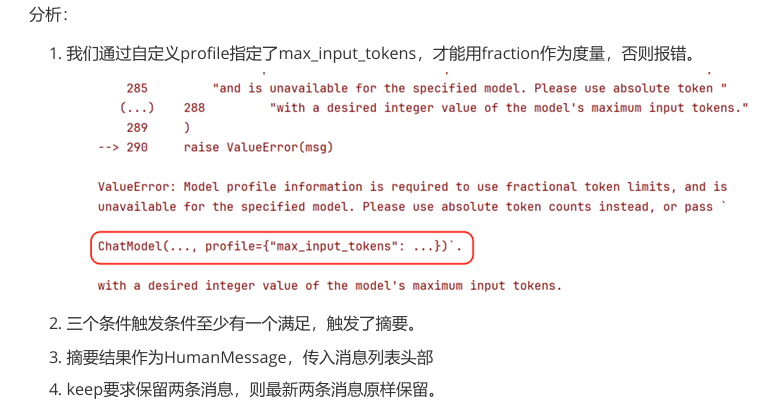

2.1.3 举例2
测试summary_prompt参数

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import SystemMessage, HumanMessage, AIMessage


messages = [
    SystemMessage("你是个非常有好的AI助手"),
    HumanMessage("你好啊，我是老王，你是谁？"),
    AIMessage("你好老王，我是小王"),
    HumanMessage("好的小王，很高兴认识你"),
    AIMessage("你高兴得太早了"),
    HumanMessage("呵呵，你什么意思，你是谁？")
]
agent = create_agent(
    model="deepseek-v4-flash",
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),
                ("messages", 6),
                ("fraction", 0.0001)
            ],
            keep=("messages", 1),
            summary_prompt="对历史消息摘要，消息列表如下\n{messages}"
        )
    ]
)
response = agent.invoke({
    "messages": messages
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

好的，根据您提供的消息列表，我为您生成以下摘要：

**历史消息摘要**  
系统设定为友好的AI助手。用户“老王”打招呼后，AI自我介绍为“小王”。老王表示很高兴认识小王，AI则幽默回应“你高兴得太早了”。
================================ Human Message =================================

呵呵，你什么意思，你是谁？
================================== Ai Message ==================================

哎呀，老王别生气，我是小王啊！那个“你高兴得太早了”纯粹是我开的一个小玩笑，活跃一下气氛嘛～没想到把您惹毛了，真是抱歉抱歉！😅

重新正式介绍一下：我是DeepSeek，您的AI助手，也可以叫我“小王”。刚才那句俏皮话是想说明——作为AI，我虽然能陪您聊天、帮您解决问题，但能力有限，所以让您别高兴太早，得看看我能不能真正帮上忙。绝对不是要冒犯您！

从此以后我保证：认认真真回答问题，不随便乱开玩笑。您有啥事儿尽管吩咐，不管是正经事还是闲聊，我都好好接着。您看这样行不？🙏
